# Projet 4 — Prédiction de la pluie demain (RainTomorrow)



Objectif : entraîner et comparer des modèles de **classification binaire** pour prédire `RainTomorrow` (Yes/No) à partir des variables météo du jour.



- Dataset : `../data/weatherAUS.csv`

- Focus évaluation : **Recall** (ne pas rater les jours de pluie), puis F1, ROC-AUC, Accuracy.

- Ce notebook sert de **prototype Python** avant de reconstruire le workflow dans **Orange Data Mining**.



## Plan du notebook

1) Charger et inspecter les données

2) Définir `X` (features) et `y` (cible)

3) Split train/test (stratifié)

4) Pipeline de prétraitement (imputation + encodage + scaling)

5) Entraîner/évaluer plusieurs modèles

6) Ajuster le seuil de décision (optionnel, orienté Recall)

7) EDA minimale + notes de transposition vers Orange


## 1) Imports & configuration



Cette section prépare l’environnement de travail.



- `RANDOM_STATE` assure la reproductibilité (split, modèles).

- `DATA_PATH` pointe vers le CSV dans `../data/`.

- On importe `sklearn` pour construire un pipeline propre (comme on le fera ensuite dans Orange).


In [ ]:
# Étape 1 — Imports & configuration
# - On centralise ici tous les imports pour éviter les surprises plus tard.
# - DATA_PATH pointe vers le fichier CSV (relatif au notebook).
# - RANDOM_STATE sert à rendre les résultats reproductibles.

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

RANDOM_STATE = 42
DATA_PATH = Path('..') / 'data' / 'weatherAUS.csv'
DATA_PATH


WindowsPath('../data/weatherAUS.csv')

## 2) Chargement des données



On charge le fichier CSV et on vérifie rapidement :

- la forme du dataset (lignes, colonnes)

- un aperçu des premières lignes


In [ ]:
# Étape 2 — Lecture du CSV
# À ce stade, on ne modifie rien: on charge juste les données.

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)

# Aperçu des premières lignes pour vérifier visuellement les colonnes.
display(df.head())


Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 3) Inspection rapide & qualité des données



But : comprendre la structure et les problèmes classiques du dataset.



- Types de colonnes (numériques vs catégorielles)

- % de valeurs manquantes (NaN)

- Distribution de la cible `RainTomorrow` (déséquilibre de classes)


In [ ]:
# Étape 3 — Qualité des données
# - df.info(): types + nb de valeurs non nulles
# - missing_%: pour repérer les colonnes très incomplètes (Sunshine, Evaporation, Cloud*)
# - value_counts cible: vérifier le déséquilibre Yes/No

display(df.info())

missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing.head(15).to_frame('missing_%'))

target_col = 'RainTomorrow'
print('Target value counts (raw):')
display(df[target_col].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

None

,missing_%
Sunshine,48.009762
Evaporation,43.166506
Cloud3pm,40.807095
Cloud9am,38.421559
Pressure9am,10.356799
Pressure3pm,10.331363
WindDir9am,7.263853
WindGustDir,7.098859
WindGustSpeed,7.055548
Humidity3pm,3.098446


Target value counts (raw):


RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

## 4) Nettoyage minimal & définition X/y



Hypothèses simples (prototype) :

- On supprime les lignes où la cible est manquante (sinon impossible d’apprendre)

- On encode la cible : `Yes -> 1`, `No -> 0`

- On retire `Date` pour éviter une mauvaise gestion de la temporalité dans un premier jet

  (une version plus avancée peut encoder la date ou faire un split temporel)


In [ ]:
# Étape 4 — Définir X (features) et y (cible)
# - On supprime les lignes où RainTomorrow est NaN.
# - Encodage binaire: Yes->1, No->0.
# - On retire Date pour cette baseline (sinon il faut l'encoder proprement).

target_col = 'RainTomorrow'

df = df.dropna(subset=[target_col]).copy()

# Encodage de la cible Yes/No -> 1/0
y = df[target_col].map({'Yes': 1, 'No': 0}).astype(int)

cols_to_drop = [target_col]
if 'Date' in df.columns:
    cols_to_drop.append('Date')

X = df.drop(columns=cols_to_drop)

print('X shape:', X.shape)
print('y mean (rain rate):', y.mean().round(4))
display(y.value_counts().rename({0: 'No', 1: 'Yes'}))


X shape: (142193, 21)
y mean (rain rate): 0.2242


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

## 5) Split train/test (stratifié)



On sépare le dataset en apprentissage et test.



- `stratify=y` garde le même taux de pluie dans train et test.

- Attention : ce split est **aléatoire**. Pour une approche temporelle réaliste, il faudrait un split par date.


In [ ]:
# Étape 5 — Split train/test
# Le split stratifié est important car la classe "pluie" est minoritaire.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train rain rate:', y_train.mean().round(4), ' Test rain rate:', y_test.mean().round(4))


Train: (113754, 21)  Test: (28439, 21)
Train rain rate: 0.2242  Test rain rate: 0.2242


## 6) Prétraitement (pipeline)



On construit un pipeline de transformation similaire à Orange :



- Numériques : imputation médiane (robuste aux outliers) + standardisation

- Catégorielles : imputation (mode) + One-Hot Encoding



Avantage pipeline : aucune fuite de données (fit sur train, transform sur test).


In [ ]:
# Étape 6 — Définir le prétraitement
# On détecte automatiquement les colonnes numériques vs catégorielles.
# Puis on assemble un ColumnTransformer pour appliquer le bon traitement à chaque groupe.

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeric:', len(numeric_features))
print('Categorical:', len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)


Numeric: 16
Categorical: 5


## 7) Fonctions d’évaluation



On définit une fonction utilitaire qui :

- calcule les métriques (Accuracy, Precision, Recall, F1, AUC)

- affiche un rapport de classification

- trace matrice de confusion + courbe ROC



Rappel : ici on privilégie **Recall** (détecter la pluie), même si cela augmente les fausses alertes.


In [ ]:
# Étape 7 — Fonction d'évaluation
# Cette fonction standardise l'évaluation pour comparer facilement les modèles.
# Elle suppose un modèle sklearn (ou pipeline) avec .predict() et idéalement .predict_proba().

def evaluate_binary_classifier(model, X_test, y_test, model_name: str = 'model'):
    """Évalue un classifieur binaire et affiche métriques + graphiques."""

    # Prédictions (classes)
    y_pred = model.predict(X_test)

    # Probabilités pour AUC/ROC si disponibles
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)

    print(f'== {model_name} ==')
    for k, v in metrics.items():
        print(f'{k:>9}: {v:.4f}')

    print('\nClassification report:')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes'], zero_division=0))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Courbe ROC si proba disponibles
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f'ROC curve — {model_name}')
        plt.show()

    return metrics


## 8) Modèle 1 — Régression Logistique (baseline)



Pourquoi ce modèle :

- rapide, robuste, facile à interpréter

- donne une bonne baseline et des probabilités bien calibrées dans beaucoup de cas



On met `class_weight='balanced'` pour compenser le déséquilibre (peu de jours de pluie).


CPU times: total: 1.27 s
Wall time: 1.31 s
== LogisticRegression (balanced) ==
 accuracy: 0.7939
precision: 0.5274
   recall: 0.7758
       f1: 0.6279
  roc_auc: 0.8726

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.80      0.86     22064
         Yes       0.53      0.78      0.63      6375

    accuracy                           0.79     28439
   macro avg       0.73      0.79      0.74     28439
weighted avg       0.84      0.79      0.81     28439



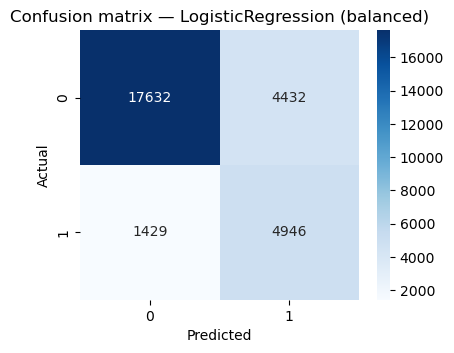

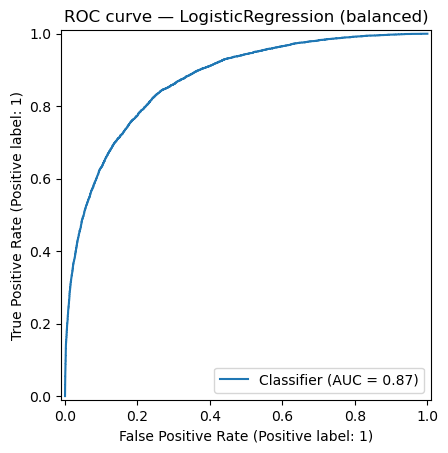

In [ ]:
# Étape 8 — Logistic Regression baseline
# - Pipeline = preprocess + modèle
# - class_weight='balanced' augmente la pénalité sur la classe minoritaire (pluie)

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None))
])

%time log_reg.fit(X_train, y_train)
_ = evaluate_binary_classifier(log_reg, X_test, y_test, model_name='LogisticRegression (balanced)')


## 9) Modèle 2 — Random Forest



Pourquoi ce modèle :

- capte des relations non linéaires

- souvent performant sur des données tabulaires



Note : sur certaines machines, une forêt trop grande peut être lente.

Ici on choisit des paramètres *raisonnables* pour garder un temps d’exécution acceptable.


CPU times: total: 58min 17s
Wall time: 8min 12s
== RandomForest (balanced_subsample) ==
 accuracy: 0.8567
precision: 0.7866
   recall: 0.4949
       f1: 0.6075
  roc_auc: 0.8914

Classification report:
              precision    recall  f1-score   support

          No       0.87      0.96      0.91     22064
         Yes       0.79      0.49      0.61      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.73      0.76     28439
weighted avg       0.85      0.86      0.84     28439



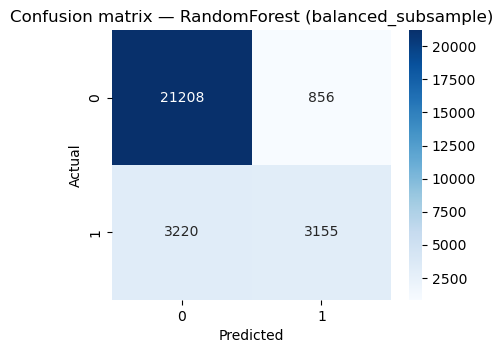

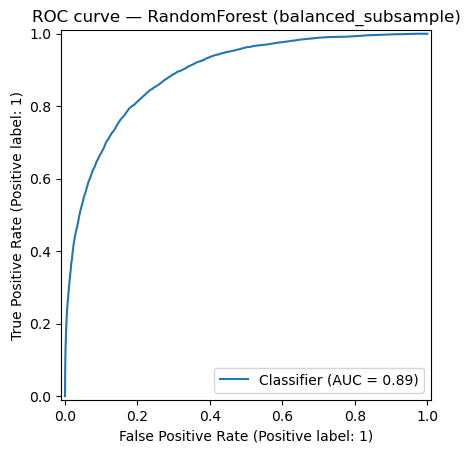

In [ ]:
# Étape 9 — RandomForest
# Paramètres "rapides" par défaut:
# - n_estimators réduit
# - max_depth/min_samples_leaf limitent la complexité (et le surapprentissage)

rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        # Paramètres plus rapides par défaut (à augmenter si besoin)
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

%time rf.fit(X_train, y_train)
_ = evaluate_binary_classifier(rf, X_test, y_test, model_name='RandomForest (balanced_subsample)')


## 10) Modèle 3 — XGBoost (si installé)



Pourquoi XGBoost :

- très performant sur données tabulaires

- gère bien des patterns non linéaires



On utilise `scale_pos_weight = n_neg / n_pos` pour aider avec le déséquilibre de classes.


scale_pos_weight: 3.4605913261704964
CPU times: total: 34 s
Wall time: 5.04 s
== XGBoost (scale_pos_weight) ==
 accuracy: 0.8132
precision: 0.5585
   recall: 0.7953
       f1: 0.6562
  roc_auc: 0.8927

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.82      0.87     22064
         Yes       0.56      0.80      0.66      6375

    accuracy                           0.81     28439
   macro avg       0.75      0.81      0.76     28439
weighted avg       0.85      0.81      0.82     28439



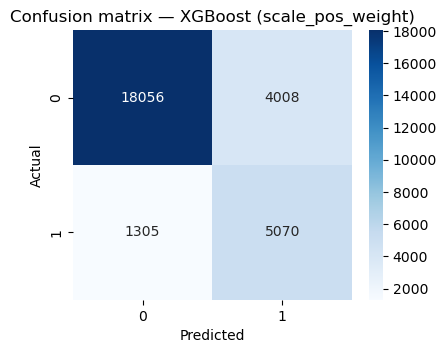

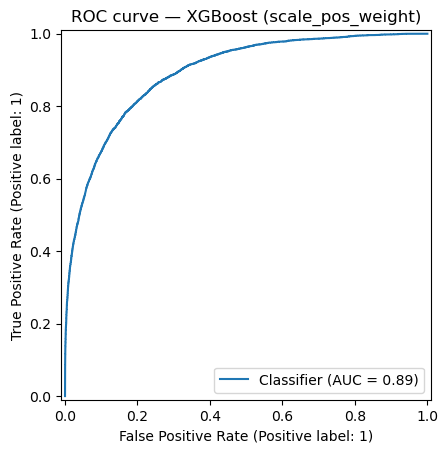

In [ ]:
# Étape 10 — Entraîner XGBoost (si la lib est installée)
# Note: on encapsule dans try/except pour que le notebook reste exécutable même sans xgboost.

try:
    from xgboost import XGBClassifier

    # scale_pos_weight = negatives / positives (train)
    # Intuition: on "pèse" davantage les erreurs sur la classe minoritaire (pluie)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    spw = (n_neg / max(n_pos, 1))

    xgb = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='logloss',
            scale_pos_weight=spw
        ))
    ])

    print('scale_pos_weight:', spw)
    %time xgb.fit(X_train, y_train)
    _ = evaluate_binary_classifier(xgb, X_test, y_test, model_name='XGBoost (scale_pos_weight)')
except Exception as e:
    print('XGBoost non disponible ou erreur dimport:', repr(e))


AUC (indépendant du seuil): 0.8926673633920573

Top seuils (triés par Recall puis F1):


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.05,0.354865,0.257318,0.995608,0.408943,0.892667
1,0.10,0.462042,0.292426,0.986039,0.451078,0.892667
2,0.15,0.542670,0.326295,0.976941,0.489200,0.892667
3,0.20,0.607230,0.359442,0.961725,0.523301,0.892667
4,0.25,0.660888,0.393093,0.942745,0.554838,0.892667
5,0.30,0.702345,0.424341,0.919373,0.580671,0.892667
6,0.35,0.737297,0.456047,0.891922,0.603513,0.892667
7,0.40,0.768909,0.491237,0.866196,0.626930,0.892667



Seuil choisi: 0.4 (contraintes recall/precision)
accuracy     0.768909
precision    0.491237
recall       0.866196
f1           0.626930


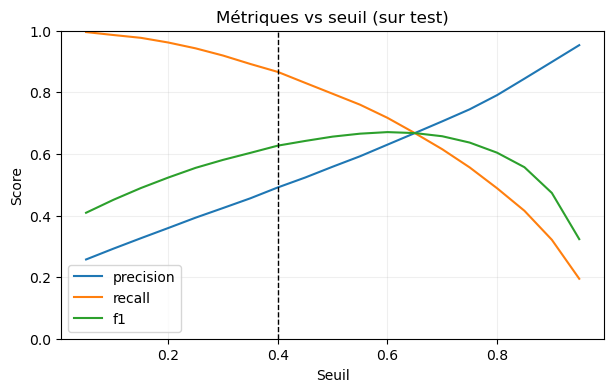

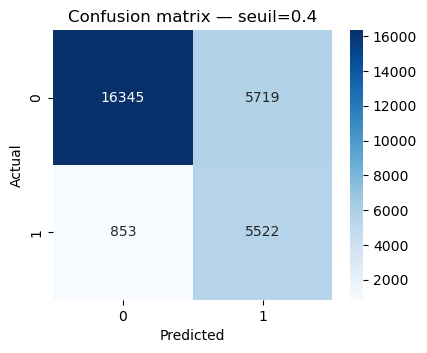

In [ ]:
# 10b) Ajuster le seuil de décision (probabilité -> classe)
# Objectif: augmenter le Recall (détecter plus de jours de pluie) au prix de plus de faux positifs.
#
# IMPORTANT (bonne pratique ML):
# - Ici on choisit le seuil sur le jeu de TEST => résultat un peu "optimiste".
# - Idéalement: split Train/Validation/Test, tuner le seuil sur Validation, puis reporter le score final sur Test.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

# Modèle à utiliser pour le réglage du seuil
model_for_threshold = xgb  # change en log_reg / rf si tu veux comparer

# Contraintes simples (à ajuster)
TARGET_RECALL = 0.85      # viser au moins ce recall si possible
MIN_PRECISION = 0.45      # éviter un modèle qui “crie pluie” tout le temps

# Grille de seuils
thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)

# Probabilités
if not hasattr(model_for_threshold, "predict_proba"):
    raise ValueError("Le modèle choisi n'expose pas predict_proba().")

y_proba = model_for_threshold.predict_proba(X_test)[:, 1]

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": float(t),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

df_thr = pd.DataFrame(rows)
df_thr["roc_auc"] = roc_auc_score(y_test, y_proba)

# Choix du seuil: d'abord on cherche à atteindre TARGET_RECALL et MIN_PRECISION, sinon meilleur F1
candidates = df_thr[(df_thr["recall"] >= TARGET_RECALL) & (df_thr["precision"] >= MIN_PRECISION)].copy()
if len(candidates) > 0:
    chosen = candidates.sort_values(["f1", "recall"], ascending=False).iloc[0]
    chosen_reason = "contraintes recall/precision"
else:
    chosen = df_thr.sort_values(["f1", "recall"], ascending=False).iloc[0]
    chosen_reason = "meilleur F1 (fallback)"

chosen_t = float(chosen["threshold"])

print("AUC (indépendant du seuil):", float(df_thr["roc_auc"].iloc[0]))
print("\nTop seuils (triés par Recall puis F1):")
display(df_thr.sort_values(["recall", "f1"], ascending=False).head(8))

print("\nSeuil choisi:", chosen_t, f"({chosen_reason})")
print(chosen[["accuracy", "precision", "recall", "f1"]].to_string())

# Visualisation des métriques vs seuil
plt.figure(figsize=(7, 4))
plt.plot(df_thr["threshold"], df_thr["precision"], label="precision")
plt.plot(df_thr["threshold"], df_thr["recall"], label="recall")
plt.plot(df_thr["threshold"], df_thr["f1"], label="f1")
plt.axvline(chosen_t, color="black", linestyle="--", linewidth=1)
plt.title("Métriques vs seuil (sur test)")
plt.xlabel("Seuil")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# Matrice de confusion au seuil choisi
y_pred_chosen = (y_proba >= chosen_t).astype(int)
cm = confusion_matrix(y_test, y_pred_chosen)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix — seuil={chosen_t}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# 10c) Choisir un seuil sous contrainte de faux positifs (FPR)
# Idée: on veut un Recall élevé, MAIS on limite le taux de fausses alertes pluie.
# FPR = FP / (FP + TN)
#
# IMPORTANT (bonne pratique ML): même remarque que pour 10b.
# Idéalement, on fixe le seuil sur un jeu de validation, puis on évalue 1 fois sur le test.

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

model_for_threshold = xgb  # log_reg / rf possible
MAX_FPR = 0.25            # ex: accepter au plus 25% de faux positifs sur la classe "No"

thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
y_proba = model_for_threshold.predict_proba(X_test)[:, 1]

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    rows.append({
        "threshold": float(t),
        "fpr": float(fpr),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    })

df_fpr = pd.DataFrame(rows)

# Choix: parmi les seuils qui respectent la contrainte FPR, maximiser Recall puis F1
candidates = df_fpr[df_fpr["fpr"] <= MAX_FPR].copy()
if len(candidates) == 0:
    print("Aucun seuil ne respecte MAX_FPR=", MAX_FPR)
    display(df_fpr.sort_values(["fpr", "recall"], ascending=[True, False]).head(10))
else:
    best = candidates.sort_values(["recall", "f1"], ascending=False).iloc[0]
    print("Seuil sous contrainte FPR choisi:", float(best["threshold"]))
    print(best[["fpr", "precision", "recall", "f1", "accuracy"]].to_string())
    print("Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}".format(**best.to_dict()))

    print("\nTop 8 candidats (FPR <= MAX_FPR), triés par Recall puis F1:")
    display(candidates.sort_values(["recall", "f1"], ascending=False).head(8))


Seuil sous contrainte FPR choisi: 0.45
fpr          0.218501
precision    0.523428
recall       0.830588
f1           0.642168
accuracy     0.792503
Confusion: TN=17243.0, FP=4821.0, FN=1080.0, TP=5295.0

Top 8 candidats (FPR <= MAX_FPR), triés par Recall puis F1:


,threshold,fpr,accuracy,precision,recall,f1,tn,fp,fn,tp
8,0.45,0.218501,0.792503,0.523428,0.830588,0.642168,17243,4821,1080,5295
9,0.50,0.181653,0.813179,0.558493,0.795294,0.656183,18056,4008,1305,5070
10,0.55,0.151061,0.828967,0.592393,0.759843,0.665750,18731,3333,1531,4844
11,0.60,0.121646,0.842224,0.630099,0.717176,0.670824,19380,2684,1803,4572
12,0.65,0.095993,0.851014,0.667713,0.667608,0.667660,19946,2118,2119,4256
13,0.70,0.074103,0.856254,0.705776,0.615216,0.657392,20429,1635,2453,3922
14,0.75,0.055067,0.857801,0.744802,0.556235,0.636853,20849,1215,2829,3546
15,0.80,0.037346,0.856394,0.790810,0.488627,0.604033,21240,824,3260,3115


## 11) EDA minimale (optionnelle)



Objectif : relier variables physiques et pluie.



Exemples rapides :

- Répartition `RainTomorrow`

- Boxplot de `Humidity3pm` selon la classe (souvent très discriminant)

- Heatmap de corrélation (variables numériques)



Cette partie est à enrichir avec tes visualisations clés pour le rapport (IMRADC).


In [ ]:
# Étape 11 — EDA minimale
# On garde ça volontairement simple (prototype).
# Astuce: si la heatmap est lourde, réduire l'échantillon ou le nb de colonnes.

plt.figure(figsize=(5, 3))
sns.countplot(x=df[target_col], order=['No', 'Yes'])
plt.title('Répartition de la cible RainTomorrow')
plt.show()

# Exemple : Humidity3pm vs RainTomorrow si la colonne existe
if 'Humidity3pm' in df.columns:
    plt.figure(figsize=(6, 3.5))
    sns.boxplot(data=df, x=target_col, y='Humidity3pm', order=['No', 'Yes'])
    plt.title('Humidity3pm vs RainTomorrow')
    plt.show()

# Corrélation des variables numériques (échantillon si trop grand)
num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
    corr = sample[num_cols].corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Matrice de corrélation (numériques) — échantillon')
    plt.show()


## 12) Notes pour la transition Orange



But : reproduire *le même pipeline* dans Orange (livrable `.ows`).



### Mapping (Python → Orange)

- Lecture CSV : **File** (importer `weatherAUS.csv`)

- Définir la cible : **Select Columns** (Target = `RainTomorrow`)

- Nettoyage manquants : **Impute** (num: median, cat: most frequent)

- Encodage catégoriel : **Continuize** / **One Hot** (selon widgets disponibles)

- Standardisation : **Normalize** (optionnel mais utile pour Logistic Regression)

- Modèles : **Logistic Regression**, **Random Forest**, **Neural Network**, (XGBoost si widget)

- Évaluation : **Test & Score** (suivre Recall/F1/AUC)

- Analyse : **Confusion Matrix**, **ROC Analysis**, **Calibration Plot**



### Checklist pratique

1) Vérifier que `RainTomorrow` est bien reconnue comme variable *discrète* (Yes/No)

2) Appliquer l’imputation avant l’apprentissage

3) Comparer au moins 2 modèles (baseline + modèle non-linéaire)

4) Reporter la matrice de confusion et expliquer le compromis Recall ↔ faux positifs
